# Market state, and the range of prices ahead

**In short.** RADAR labels each market calm, normal or turbulent from its own price
history, using only what was known that day. From today's label it simulates thousands
of possible futures and reports the range they cover. The label describes the present
and does not forecast a change; the range has held about as often as it claims.

**Two parts.** Part 1 is the state model (a hidden Markov model). Part 2 is the range
(a Monte Carlo simulation that starts from the state) and the check of how often past
ranges held.

Rebuild with `uv run python backend/scripts/build_notebooks.py 02_state_and_range`.

---

# Part 1. The state

# Market regimes: calm, normal, turbulent

**The question.** What kind of market is this right now?

**The method, in one paragraph.** Each day is described by two numbers: the day's
return and how much the price swung inside the day (smoothed over about five days). A
hidden Markov model assumes the market is always in one of three unseen states, each
with its own typical return and swing size, and that states tend to persist. From the
history of those two numbers it works out what the three states look like and how
likely each one is to follow another.

**The one rule that matters.** The state shown for any day uses only that day and
earlier days ("filtered"). Using later days as well ("smoothed") looks better on a
chart but would be cheating, because on the day itself the future was not known.

Rebuild with `uv run python backend/scripts/build_notebooks.py 02_regime`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from radar.db.session import make_engine, session_scope
from radar.models import regime
from radar.pipelines.datasets import build_regime_observations, load_field, stock_daily
from radar.pipelines.regime import current_model
from radar.universe import get_universe

plt.rcParams.update({"figure.figsize": (11, 3.4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
COLOURS = {"calm": "#3ddc97", "normal": "#9a9daa", "turbulent": "#ff6b5e"}
engine, universe = make_engine(), get_universe()

observations, models, closes = {}, {}, {}
with session_scope(engine) as session:
    for asset in universe.primary:
        observations[asset.symbol] = build_regime_observations(session, asset)
        models[asset.symbol] = regime.RegimeModel.model_validate(current_model(session, asset.symbol).params)
        metrics = current_model(session, asset.symbol).metrics
        models[asset.symbol + ":metrics"] = metrics
        if asset.asset_class == "crypto":
            closes[asset.symbol] = load_field(session, [asset.symbol], "1Day")[asset.symbol].dropna()
        else:
            closes[asset.symbol] = stock_daily(session, [asset.symbol])[asset.symbol].dropna()
symbols = [a.symbol for a in universe.primary]

## 1. The inputs

`ret` is the daily log return. `rv` is realised volatility: the size of the day's
swings, built from hourly prices. `log_rv` is its logarithm, smoothed with a trailing
five-day half-life, which is what the model sees.

In [2]:
pd.DataFrame(
    {
        s: {
            "days": len(observations[s]),
            "from": observations[s].index[0].date(),
            "to": observations[s].index[-1].date(),
            "median daily swing": observations[s]["rv"].median(),
            "largest daily swing": observations[s]["rv"].max(),
        }
        for s in symbols
    }
).T

,days,from,to,median daily swing,largest daily swing
BTC/USD,2102,2021-01-02,2026-10-04,0.0226,0.1946
GLD,2702,2016-01-05,2026-10-02,0.0068,0.0725
SPY,2702,2016-01-05,2026-10-02,0.0066,0.1263


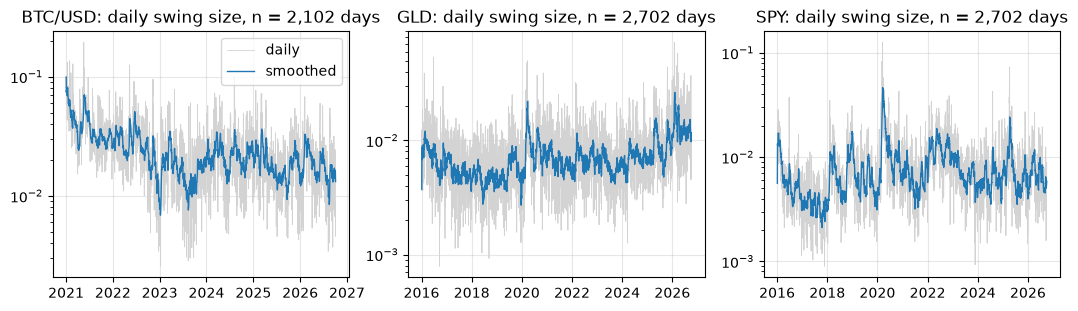

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, s in zip(axes, symbols):
    ax.plot(observations[s].index, observations[s]["rv"], color="lightgrey", linewidth=0.6, label="daily")
    ax.plot(observations[s].index, np.exp(observations[s]["log_rv"]), color="tab:blue", linewidth=1, label="smoothed")
    ax.set(title=f"{s}: daily swing size, n = {len(observations[s]):,} days", yscale="log")
axes[0].legend();

Volatility comes in clusters: quiet stretches and rough stretches. That clustering is
what makes the idea of "states" reasonable.

## 2. The fitted states

For each market: what a typical day looks like in each state, how long a stay in the
state usually lasts, and what usually comes next.

In [4]:
rows = []
for s in symbols:
    for state in regime.transition_summary(models[s]):
        rows.append(
            {
                "market": s,
                "state": state.label,
                "typical daily swing": state.typical_daily_volatility,
                "typical stay (days)": state.typical_duration_days,
                "usually next": max(state.next_states, key=state.next_states.get),
            }
        )
pd.DataFrame(rows).set_index(["market", "state"])

typical daily swing  typical stay (days) usually next
market  state                                                           
BTC/USD calm                    0.0145              36.9941       normal
        normal                  0.0223              20.4821         calm
        turbulent               0.0358              33.4518       normal
GLD     calm                    0.0050              41.7290       normal
        normal                  0.0073              30.6219         calm
        turbulent               0.0120              39.8939       normal
SPY     calm                    0.0039              33.1030       normal
        normal                  0.0060              22.1464    turbulent
        turbulent               0.0110              41.0217       normal

### Why three states?

BIC is a score that rewards fit and penalises complexity; lower is better. It often
prefers four states. Three are used anyway so that calm, normal, and turbulent mean
the same thing for every market. The table shows what was given up.

In [5]:
pd.DataFrame({s: models[s].bic_by_states for s in symbols}).rename_axis("states").round(0)

,BTC/USD,GLD,SPY
states,,,
2,9743.0000,12511.0000,11693.0000
3,8575.0000,10479.0000,9955.0000
4,7687.0000,9482.0000,8706.0000


## 3. The states through time

Price, shaded by the state the model assigned **on that day, with no knowledge of
later days**.

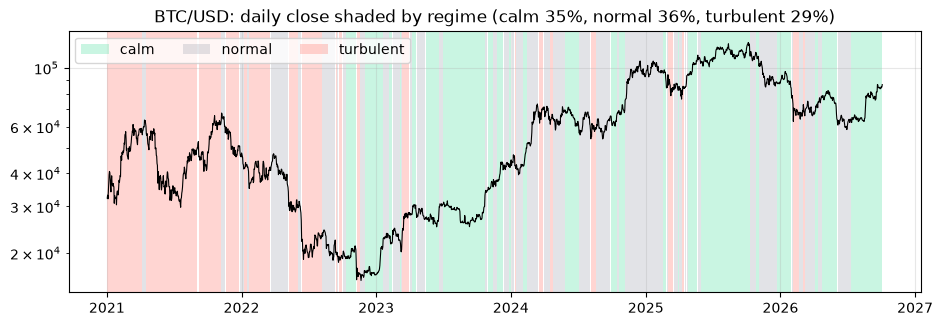

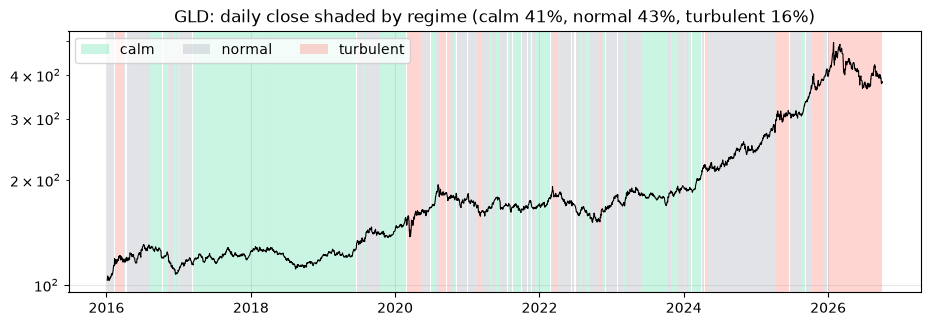

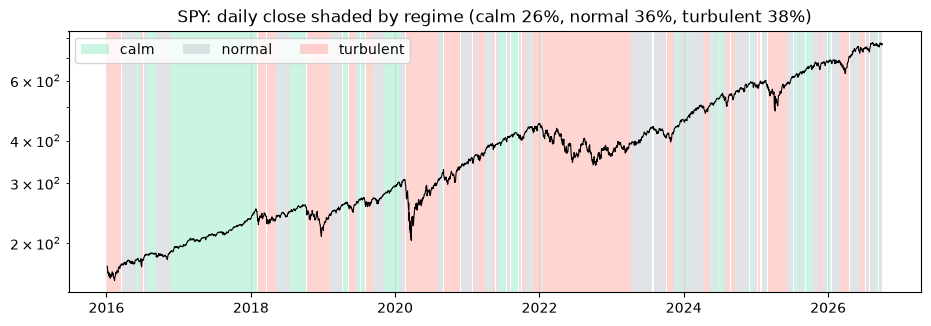

In [6]:
for s in symbols:
    probabilities = regime.filtered_probabilities(models[s], observations[s])
    labels = probabilities.idxmax(axis=1)
    price = closes[s].reindex(labels.index).ffill()
    fig, ax = plt.subplots()
    ax.plot(price.index, price.values, color="black", linewidth=0.8)
    ax.set_yscale("log")
    low, high = ax.get_ylim()
    for label, colour in COLOURS.items():
        ax.fill_between(price.index, low, high, where=(labels == label).to_numpy(), color=colour, alpha=0.28, label=label, linewidth=0)
    share = labels.value_counts(normalize=True)
    ax.set(title=f"{s}: daily close shaded by regime (" + ", ".join(f"{k} {share.get(k, 0):.0%}" for k in COLOURS) + ")", ylim=(low, high))
    ax.legend(loc="upper left", ncol=3)

### Filtered against smoothed: what hindsight changes

The last 250 days of turbulent-state probability for Bitcoin, both ways. Smoothed
(dashed) reacts earlier because it has seen what came next. The app only ever uses
the solid line.

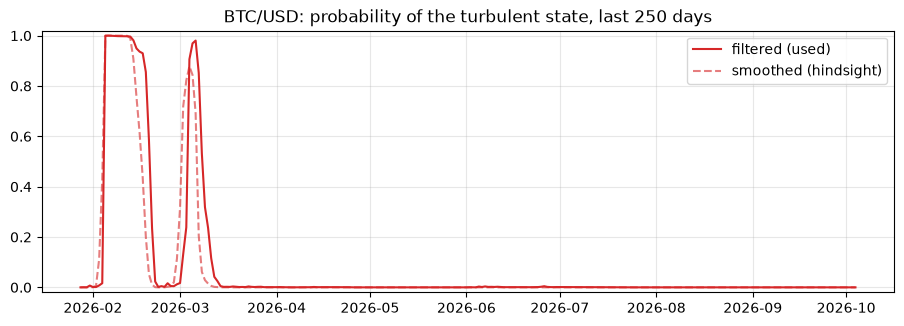

In [7]:
s = symbols[0]
filtered = regime.filtered_probabilities(models[s], observations[s])["turbulent"].iloc[-250:]
smoothed = regime.smoothed_probabilities(models[s], observations[s])["turbulent"].iloc[-250:]
fig, ax = plt.subplots()
ax.plot(filtered.index, filtered.values, color="tab:red", label="filtered (used)")
ax.plot(smoothed.index, smoothed.values, color="tab:red", linestyle="--", alpha=0.6, label="smoothed (hindsight)")
ax.set(title=f"{s}: probability of the turbulent state, last 250 days", ylim=(-0.02, 1.02))
ax.legend();

## 4. Does it work on days it had not seen?

Walk-forward test: the model is fitted on history up to a date, then labels the next
63 days it has never seen; then it is refitted and the window moves on. Every number
below comes from those unseen days.

The test of usefulness: after a day labelled turbulent, the **next** day's swings
should be larger than after a day labelled calm.

In [8]:
walk = {s: models[s + ":metrics"]["walk_forward"] for s in symbols}
pd.DataFrame(
    {
        s: {
            "unseen days tested": w["n_days"],
            "from": w["first_test_day"],
            "to": w["last_test_day"],
            **{f"next-day swing after {k}": v for k, v in w["next_day_volatility"].items()},
            "in the right order": w["volatility_is_ordered"],
            "average run of one state (days)": w["average_run_length"],
        }
        for s, w in walk.items()
    }
).T

,unseen days tested,from,to,next-day swing after calm,next-day swing after normal,next-day swing after turbulent,in the right order,average run of one state (days)
BTC/USD,1602,2022-05-17,2026-10-04,0.0196,0.0271,0.0363,True,34.0851
GLD,2202,2017-12-28,2026-10-02,0.0061,0.0075,0.0114,True,16.8092
SPY,2202,2017-12-28,2026-10-02,0.0054,0.0067,0.0124,True,21.8020


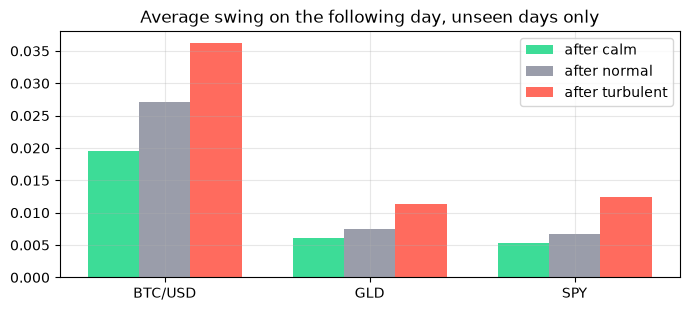

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.2))
width = 0.25
for i, label in enumerate(COLOURS):
    ax.bar(np.arange(len(symbols)) + (i - 1) * width, [walk[s]["next_day_volatility"][label] for s in symbols], width, color=COLOURS[label], label=f"after {label}")
ax.set(xticks=np.arange(len(symbols)), xticklabels=symbols, title="Average swing on the following day, unseen days only")
ax.legend();

### Against a simple rule

The rival is a rule with no model: sort days into three groups by their average
volatility over the previous 30 days. Both are scored by how well they predicted each
unseen day's return and swing (average log density; higher is better).

In [10]:
pd.DataFrame(
    {
        s: {
            "hidden Markov model": w["model_log_density"],
            "30-day rule": w["baseline_log_density"],
            "model is better": w["model_log_density"] > w["baseline_log_density"],
        }
        for s, w in walk.items()
    }
).T

,hidden Markov model,30-day rule,model is better
BTC/USD,2.0168,1.9721,True
GLD,3.4400,3.0538,True
SPY,3.1835,2.5584,True


## What to take from this

- The states are real in the sense that matters: on unseen days, rougher states were
  followed by larger swings, for all three markets.
- A regime is detected **after** it begins. The model describes the present; it does
  not call turning points.
- Crypto history starts in 2021, so its states are learned from few market cycles.

---

# Part 2. The range ahead

# Outlook: a range of outcomes, and how often past ranges held

**The question.** What range of prices is plausible over the next day, week, or month?

**The method.** A Monte Carlo simulation: play out 10,000 possible futures and look at
where they end. Each future starts from today's regime probabilities. For every day
ahead it first draws the next regime (using how regimes have followed each other),
then draws that day's return from the **real past returns seen in that regime**.
Drawing real returns keeps the occasional very large move that a textbook bell curve
would miss.

**Why you can check it.** For every past day, the same simulation is run using only
what was known then, and its ranges are compared with what happened next. If the "80%
range" really is one, it should have contained the outcome about 80% of the time.

Rebuild with `uv run python backend/scripts/build_notebooks.py 03_outlook`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import select

from radar.db.models import CalibrationReport
from radar.db.session import make_engine, session_scope
from radar.models import calibration, regime, simulator
from radar.pipelines import simulation as job
from radar.pipelines.datasets import build_regime_observations
from radar.pipelines.regime import current_model
from radar.universe import get_universe

plt.rcParams.update({"figure.figsize": (11, 3.4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
engine, universe = make_engine(), get_universe()
asset = universe.get("BTC/USD")

with session_scope(engine) as session:
    observations = build_regime_observations(session, asset)
    model = regime.RegimeModel.model_validate(current_model(session, asset.symbol).params)
    run = job.latest(session, asset.symbol)
    stored_paths = job.decode_paths(run)
    stored = {"seed": run.seed, "as_of": run.as_of, "start_price": run.start_price, "n_paths": run.n_paths,
              "horizons": run.horizons}
    reports = pd.read_sql(select(CalibrationReport), session.connection())

## 1. One simulation, step by step (Bitcoin)

First, sort every past return by the regime of its day. These are the "pools" the
simulation draws from. Notice how much wider the turbulent pool is.

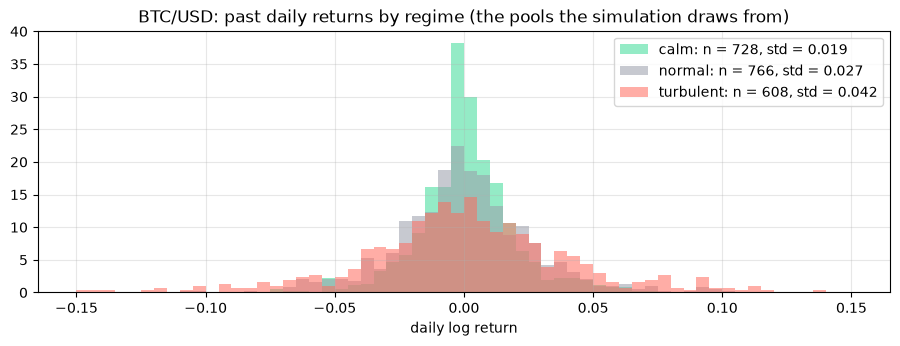

In [2]:
clean = observations.dropna(subset=list(regime.FEATURES))
probabilities = regime.filtered_probabilities(model, clean).to_numpy()
returns = clean["ret"].to_numpy()
pools, thin = simulator.build_pools(returns, probabilities.argmax(axis=1), model.n_states)

fig, ax = plt.subplots()
bins = np.linspace(-0.15, 0.15, 61)
for label, pool, colour in zip(model.labels, pools, ("#3ddc97", "#9a9daa", "#ff6b5e")):
    ax.hist(pool, bins=bins, density=True, alpha=0.55, color=colour, label=f"{label}: n = {len(pool):,}, std = {pool.std():.3f}")
ax.set(title=f"{asset.symbol}: past daily returns by regime (the pools the simulation draws from)", xlabel="daily log return")
ax.legend();

In [3]:
print("Today's regime probabilities:", dict(zip(model.labels, probabilities[-1].round(3))))
pd.DataFrame(model.transition, index=model.labels, columns=model.labels).rename_axis("from / to").round(3)

Today's regime probabilities: {'calm': np.float64(1.0), 'normal': np.float64(0.0), 'turbulent': np.float64(0.0)}


,calm,normal,turbulent
from / to,,,
calm,0.9730,0.0260,0.0010
normal,0.0270,0.9510,0.0210
turbulent,0.0000,0.0300,0.9700


The table above is the chance of moving from one regime (row) to another (column) in
a day. The large numbers on the diagonal are why regimes persist.

### Reproducible from a seed

The app stores each run's random seed. Re-running with that seed and the same data
must give exactly the stored paths; otherwise a displayed number could not be traced.

In [4]:
inputs = simulator.SimulationInputs(probabilities[-1], np.array(model.transition), pools, returns)
again = simulator.cumulative_returns(simulator.simulate(inputs, 30, n_paths=stored["n_paths"], seed=stored["seed"]))
print(f"stored run: as of {stored['as_of']:%Y-%m-%d}, seed {stored['seed']}, {stored['n_paths']:,} paths")
print("largest difference between the stored paths and a rerun:", float(np.abs(again - stored_paths).max()))

stored run: as of 2026-10-05, seed 3626675985, 10,000 paths
largest difference between the stored paths and a rerun: 2.938370080585173e-08


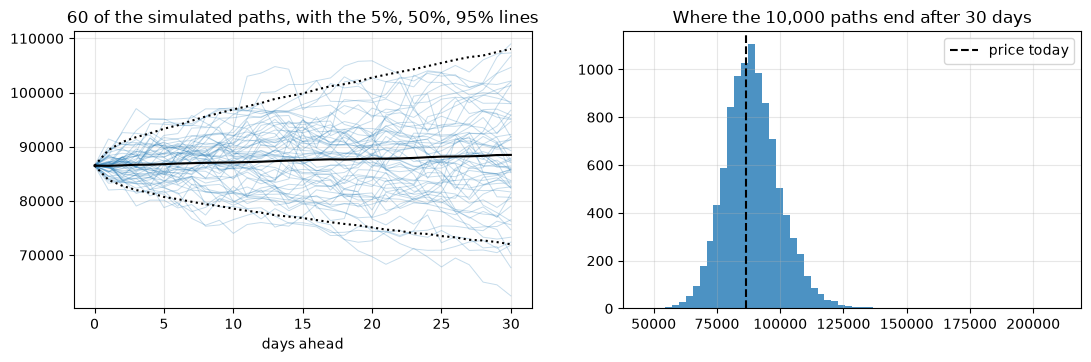

In [5]:
prices = stored["start_price"] * np.exp(stored_paths)
days = np.arange(0, 31)
with_start = np.column_stack([np.full(len(prices), stored["start_price"]), prices])
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(days, with_start[:60].T, color="tab:blue", alpha=0.25, linewidth=0.7)
for q, style in ((0.05, ":"), (0.5, "-"), (0.95, ":")):
    axes[0].plot(days, np.quantile(with_start, q, axis=0), color="black", linestyle=style)
axes[0].set(title="60 of the simulated paths, with the 5%, 50%, 95% lines", xlabel="days ahead")
axes[1].hist(prices[:, -1], bins=60, color="tab:blue", alpha=0.8)
axes[1].axvline(stored["start_price"], color="black", linestyle="--", label="price today")
axes[1].set(title=f"Where the {stored['n_paths']:,} paths end after 30 days")
axes[1].legend();

### Two different questions about a price level

"Will it **end** above X?" and "Will it **touch** X at some point?" have different
answers. Touching is always at least as likely.

In [6]:
level = round(stored["start_price"] * 1.10, -2)
pd.DataFrame(
    [simulator.level_probabilities(stored_paths, steps, stored["start_price"], level).model_dump() for steps in (1, 7, 30)]
).set_index("steps")[["level", "ends_above", "touches"]]

,level,ends_above,touches
steps,,,
1,95200.0000,0.0000,0.0000
7,95200.0000,0.0432,0.0544
30,95200.0000,0.2629,0.4116


## 2. Checking it against history

For every day after the first 500, with the regime model refitted on earlier days
only, the simulation was run and its 50%, 80%, and 95% ranges compared with what
happened. "Raw" is the simulation as it is. "Adjusted" applies a correction that
widens the range after misses and narrows it after hits, using earlier results only
(adaptive conformal inference).

In [7]:
table = reports.assign(
    raw=reports["empirical"], adjusted=reports["empirical_conformal"]
).pivot_table(index=["symbol", "horizon_days"], columns="nominal", values=["raw", "adjusted"])
table.round(3)

adjusted                  raw              
nominal                0.5000 0.8000 0.9500 0.5000 0.8000 0.9500
symbol  horizon_days                                            
BTC/USD 1              0.5040 0.8010 0.9490 0.5250 0.8180 0.9530
        7              0.5030 0.8030 0.9470 0.5820 0.8330 0.9350
        30             0.4980 0.8030 0.9480 0.5790 0.7950 0.9320
GLD     1              0.5010 0.8010 0.9500 0.4770 0.7810 0.9350
        7              0.5010 0.8010 0.9500 0.5040 0.7900 0.9210
        30             0.4970 0.8010 0.9450 0.4830 0.7700 0.9330
SPY     1              0.4990 0.8000 0.9500 0.4850 0.7900 0.9430
        7              0.5020 0.8010 0.9500 0.5130 0.8170 0.9540
        30             0.5040 0.8050 0.9520 0.5330 0.8500 0.9460

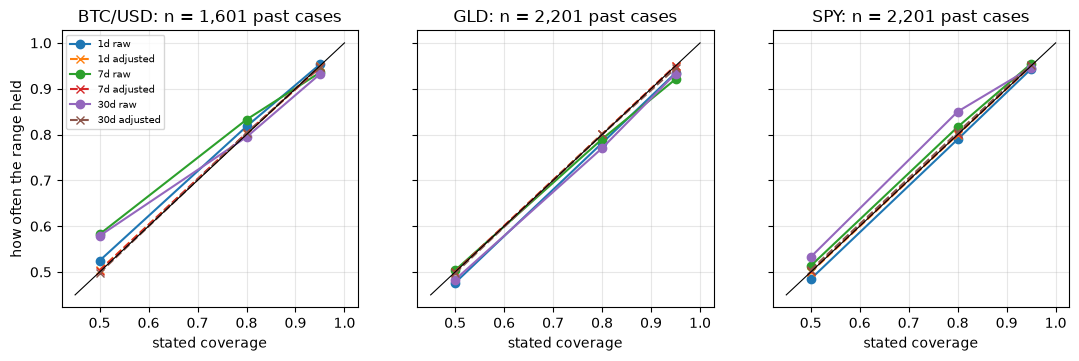

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, (symbol, group) in zip(axes, reports.groupby("symbol")):
    for horizon, part in group.groupby("horizon_days"):
        part = part.sort_values("nominal")
        ax.plot(part["nominal"], part["empirical"], marker="o", label=f"{horizon}d raw")
        ax.plot(part["nominal"], part["empirical_conformal"], marker="x", linestyle="--", label=f"{horizon}d adjusted")
    ax.plot([0.45, 1], [0.45, 1], color="black", linewidth=0.8)
    ax.set(title=f"{symbol}: n = {int(group['n'].max()):,} past cases", xlabel="stated coverage")
axes[0].set(ylabel="how often the range held")
axes[0].legend(fontsize=7);

Points on the black line are perfectly calibrated. Above the line the ranges were too
wide (held more often than stated); below, too narrow.

## 3. Against a simple forecast

The rival is a random walk with constant volatility from the trailing year. Both are
scored by pinball loss, a standard score for forecast ranges; lower is better.

In [9]:
loss = reports.drop_duplicates(["symbol", "horizon_days"])[["symbol", "horizon_days", "n", "pinball_model", "pinball_baseline"]].copy()
loss["simulator against simple forecast"] = loss["pinball_model"] / loss["pinball_baseline"] - 1
loss.set_index(["symbol", "horizon_days"]).style.format({"simulator against simple forecast": "{:+.1%}", "pinball_model": "{:.5f}", "pinball_baseline": "{:.5f}"})

A negative percentage means the simulator's error was smaller. It is not better
everywhere, and the app says so where it is not.

## What to take from this

- The ranges are honest in the measurable sense: they have held about as often as
  they state, and the adjustment brings them closer still.
- The simulation assumes the future resembles the sampled past. A kind of move that
  has never happened in the data cannot appear in it.
- For the 95% range at long horizons the adjustment is sometimes at its widest
  setting, so that range covers nearly every simulated outcome.